Sample code to emulate a forward run using pre-computed footprints

In [ ]:
from omegaconf import OmegaConf
from pandas import date_range, DataFrame
import xarray as xr
from pathlib import Path
from tm5.fitic import read_obs_table


# TM5 run has been prepared without any emissions (just forward propagation of the initial condition)
conf = OmegaConf.load('background_20260331_gns1x1.yaml')
conf.host = conf.cosmos

# Load the observations table
obs_table = read_obs_table(conf.observations.file).set_index('obsid')
tracers = set(obs_table.tracer)

# Accumulators:
date, region, obs, dmix = [], [], [], []

for day in date_range(conf.run.start, conf.run.end, freq='1d'):
    for reg in conf.run.regions:
        adjfile = day.strftime(f'{conf.run.paths.output}/adjemis/adjemis.{reg}.%Y%m%d.nc')
        
        # Adjoint files are written only if needed, so it may not exist for a given day/region
        if not Path(adjfile).exists():
            continue
        
        # I don't know which key should code for that exact path ... for now I guessed ...
        adj = xr.open_dataset(day.strftime(f'{conf.run.paths.output}/adjemis/adjemis.{reg}.%Y%m%d.nc'))
        
        ilons = adj.ilon.values
        ilats = adj.ilat.values
        sensi = adj['values'].values
        itrac = adj.itrac.values
            
        # Read the emissions. For now, I'm hardcoding this to CH4 ...
        em = xr.open_dataset(day.strftime(f'{conf.emissions.CH4.prefix}.CH4.{reg}.%Y%m%d.nc'))
        emtot = em.to_array().sum('variable').values
        
        for itr in set(itrac):
            date.append(day)
            region.append(reg)
            obs.append(adj.tracer.values[itr].strip().decode())
            
            subset = itrac == itr
            dmix.append((emtot[ilats[subset], ilons[subset]] * sensi[subset]).sum())
            
# Store everything in a common dataframe. Each row contains the contribution of one date and region to one specific obs
fwd = DataFrame.from_dict({'obs': obs, 'region': region, 'date': date, 'mix': dmix})

# Do some plots with what we just computed:

## 1. Contribution of the emissions each date to each observation:

array([<Axes: xlabel='date'>, <Axes: xlabel='date'>,
       <Axes: xlabel='date'>, <Axes: xlabel='date'>], dtype=object)

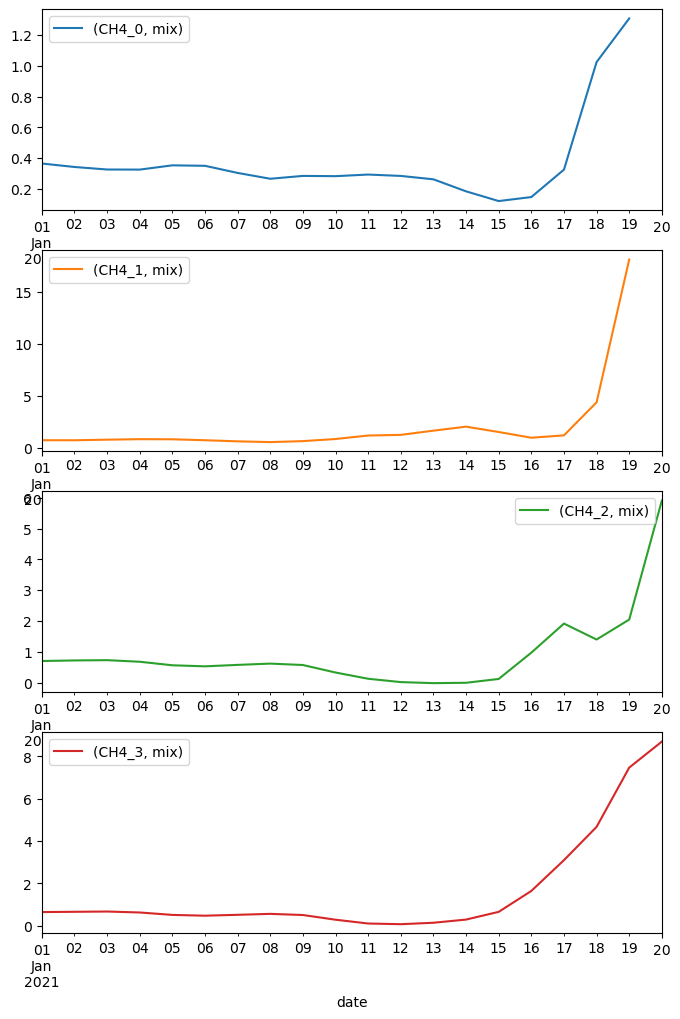

In [57]:
fwd.groupby(['obs', 'date']).sum(numeric_only=True).reset_index().plot(by='obs', x='date', figsize=(8, 12))

# 2. Contribution of each region to each observations:

array([<Axes: xlabel='region'>, <Axes: xlabel='region'>,
       <Axes: xlabel='region'>, <Axes: xlabel='region'>], dtype=object)

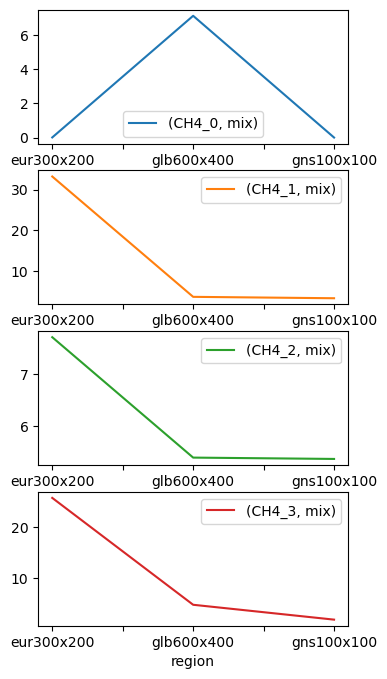

In [58]:
fwd.groupby(['obs', 'region']).sum(numeric_only=True).reset_index().plot(by='obs', x='region', figsize=(4, 8))

# 3. Timeseries (without initial condition ...)

For this, we need to recombine with the original `obs_table` dataframe.

Right now it's a bit silly because the obs are from different sites ...

<Axes: xlabel='time'>

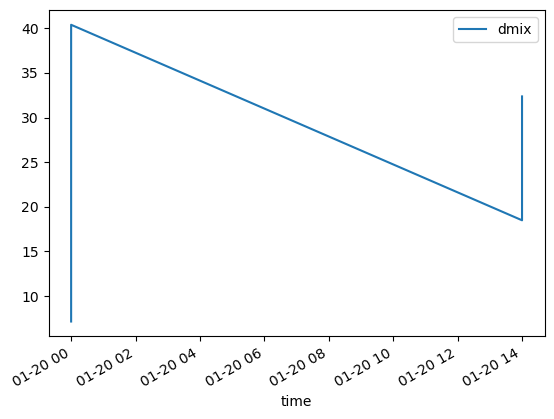

In [61]:
ym = fwd.groupby('obs').sum(numeric_only=True)
obs_table.loc[ym.index.values, 'dmix'] = ym.mix.values
obs_table.plot(x='time', y='dmix')